# Sparse Root Runtime Tradeoffs

This notebook focuses on **runtime-oriented** questions for the sparse-root model using **real Minecraft/Voxy data** and real trained checkpoints where available.

Questions addressed here:

- What is the current CPU inference cost on real inputs?
- Which parts of the unified model dominate parameter count and activation volume?
- What would a 5-model ladder cost in memory and compute if we keep current dimensions?
- How much could low-rank child projection or reduced hidden sizes save?
- Is distillation justified from a runtime perspective?

In [6]:
from __future__ import annotations

import importlib
import sys
import time
from pathlib import Path

import numpy as np
import torch

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


def find_repo_root(start: Path | None = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / "LODiffusion").exists() and (candidate / "VoxelTree").exists():
            return candidate
    raise RuntimeError("Could not locate repo root containing LODiffusion/ and VoxelTree/")


REPO_ROOT = find_repo_root()
VOXELTREE_ROOT = REPO_ROOT / "VoxelTree"
for p in (REPO_ROOT, VOXELTREE_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import LODiffusion.models.sparse_root as sparse_root_mod
import VoxelTree.core.sparse_root_train as sparse_root_train_mod

sparse_root_mod = importlib.reload(sparse_root_mod)
sparse_root_train_mod = importlib.reload(sparse_root_train_mod)

SparseRootModel = sparse_root_mod.SparseRootModel
SparseRootFastModel = sparse_root_mod.SparseRootFastModel
SparseRootDataset = sparse_root_train_mod.SparseRootDataset

DATA_PATH = REPO_ROOT / "noise_training_data" / "sparse_root_pairs.npz"
CHECKPOINT_CANDIDATES = [
    REPO_ROOT / "tmp_fast80_real_sparse_root.pt",
    REPO_ROOT / "tmp_fast72_real_sparse_root.pt",
    REPO_ROOT / "tmp_real_sparse_root_model.pt",
    REPO_ROOT / "noise_training_data" / "sparse_root_model_test.pt",
    REPO_ROOT / "tmp_sparse_root_model.pt",
]
CHECKPOINT_PATH = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
DEVICE = "cpu"

assert DATA_PATH.exists(), f"Missing real sparse-root dataset: {DATA_PATH}"
assert CHECKPOINT_PATH is not None, "No sparse-root checkpoint found."

print("repo_root      =", REPO_ROOT)
print("data_path       =", DATA_PATH)
print("checkpoint_path =", CHECKPOINT_PATH)

repo_root      = C:\Users\JeffHall\git\MC
data_path       = C:\Users\JeffHall\git\MC\noise_training_data\sparse_root_pairs.npz
checkpoint_path = C:\Users\JeffHall\git\MC\tmp_fast80_real_sparse_root.pt


In [7]:
def checkpoint_metadata(path: Path) -> dict:
    state = torch.load(path, map_location="cpu", weights_only=True)
    if isinstance(state, dict) and "model" in state and isinstance(state["model"], dict):
        state = state["model"]

    variant = "fast" if any(k.startswith("level_mod.") for k in state) else "baseline"
    if "label_head.out_proj.bias" in state:
        num_classes = int(state["label_head.out_proj.bias"].shape[0])
    elif "label_head.bias" in state:
        num_classes = int(state["label_head.bias"].shape[0])
    elif "label_head.out_proj.weight" in state:
        num_classes = int(state["label_head.out_proj.weight"].shape[0])
    elif "label_head.weight" in state:
        num_classes = int(state["label_head.weight"].shape[0])
    else:
        raise KeyError("Could not infer num_classes from checkpoint")

    if variant == "fast":
        hidden = int(state["root_proj.0.weight"].shape[0])
        model_cls = SparseRootFastModel
    else:
        hidden = int(state["root_proj.weight"].shape[0])
        model_cls = SparseRootModel

    return {
        "state": state,
        "variant": variant,
        "hidden": hidden,
        "num_classes": num_classes,
        "model_cls": model_cls,
    }


ds = SparseRootDataset(DATA_PATH)
sample = ds[0]
N2D = int(sample["noise_2d"].shape[0])
N3D = int(sample["noise_3d"].shape[0])
model_meta = checkpoint_metadata(CHECKPOINT_PATH)
NUM_CLASSES = model_meta["num_classes"]

model = model_meta["model_cls"](
    n2d=N2D,
    n3d=N3D,
    hidden=model_meta["hidden"],
    num_classes=NUM_CLASSES,
).to(DEVICE)
model.load_state_dict(model_meta["state"], strict=True)
model.eval()

print("dataset_size =", len(ds))
print("n2d          =", N2D)
print("n3d          =", N3D)
print("num_classes  =", NUM_CLASSES)
print("variant      =", model_meta["variant"])
print("hidden       =", model_meta["hidden"])

dataset_size = 296
n2d          = 0
n3d          = 13
num_classes  = 1040
variant      = fast
hidden       = 80


In [8]:
def count_parameters(module) -> int:
    return sum(p.numel() for p in module.parameters())


def param_breakdown(model: SparseRootModel):
    rows = []
    for name, param in model.named_parameters():
        rows.append({"name": name, "params": int(param.numel())})
    rows.sort(key=lambda r: r["params"], reverse=True)
    return rows


breakdown_rows = param_breakdown(model)
total_params = count_parameters(model)
print("total_params =", total_params)
if pd is not None:
    display(pd.DataFrame(breakdown_rows))
else:
    for row in breakdown_rows:
        print(row)

total_params = 247067


,name,params
0,noise_enc.mlp.0.weight,66560
1,label_head.out_proj.weight,55120
2,child_proj.out_proj.weight,25600
3,noise_enc.mlp.2.weight,12800
4,level_mod.0.proj.weight,12800
5,level_mod.1.proj.weight,12800
6,level_mod.2.proj.weight,12800
7,level_mod.3.proj.weight,12800
8,level_mod.4.proj.weight,12800
9,root_proj.0.weight,6400


In [ ]:
def level_shapes(max_level: int = 4):
    rows = []
    for lvl in range(max_level, -1, -1):
        side = 2 ** (max_level - lvl)
        nodes = side**3
        rows.append({"level": lvl, "side": side, "nodes": nodes})
    return rows


shape_rows = level_shapes()
if pd is not None:
    display(pd.DataFrame(shape_rows))
else:
    for row in shape_rows:
        print(row)

In [9]:
@torch.no_grad()
def benchmark_inference(model, dataset, batch_size: int = 1, steps: int = 64, warmup: int = 8):
    count = min(len(dataset), steps)
    items = [dataset[i] for i in range(count)]

    def stack_batch(chunk):
        noise_2d = torch.stack([item["noise_2d"] for item in chunk], dim=0).to(DEVICE)
        noise_3d = torch.stack([item["noise_3d"] for item in chunk], dim=0).to(DEVICE)
        return noise_2d, noise_3d

    batches = [items[i : i + batch_size] for i in range(0, len(items), batch_size)]

    for chunk in batches[:warmup]:
        noise_2d, noise_3d = stack_batch(chunk)
        _ = model(noise_2d, noise_3d)

    timings = []
    for chunk in batches:
        noise_2d, noise_3d = stack_batch(chunk)
        t0 = time.perf_counter()
        _ = model(noise_2d, noise_3d)
        t1 = time.perf_counter()
        timings.append(t1 - t0)

    total_items = sum(len(chunk) for chunk in batches)
    mean_batch_s = float(np.mean(timings))
    mean_item_ms = 1000.0 * sum(timings) / max(total_items, 1)
    return {
        "batch_size": batch_size,
        "num_batches": len(batches),
        "mean_batch_ms": 1000.0 * mean_batch_s,
        "mean_item_ms": mean_item_ms,
        "items_per_sec": total_items / max(sum(timings), 1e-9),
    }


benchmarks = [benchmark_inference(model, ds, batch_size=bs, steps=64) for bs in (1, 8, 32)]
if pd is not None:
    display(pd.DataFrame(benchmarks))
else:
    for row in benchmarks:
        print(row)

,batch_size,num_batches,mean_batch_ms,mean_item_ms,items_per_sec
0,1,64,5.044159,5.044159,198.249088
1,8,8,16.050000,2.006250,498.442368
2,32,2,62.403800,1.950119,512.789284


In [5]:
def estimate_dense_linear_cost(in_features: int, out_features: int) -> int:
    return in_features * out_features


def child_projection_cost(hidden: int) -> dict:
    dense = estimate_dense_linear_cost(hidden, hidden * 8)
    low_rank_half = estimate_dense_linear_cost(hidden, hidden // 2) + estimate_dense_linear_cost(
        hidden // 2, hidden * 8
    )
    low_rank_quarter = estimate_dense_linear_cost(hidden, hidden // 4) + estimate_dense_linear_cost(
        hidden // 4, hidden * 8
    )
    return {
        "hidden": hidden,
        "dense_child_proj_params": dense,
        "low_rank_half_params": low_rank_half,
        "low_rank_quarter_params": low_rank_quarter,
        "half_vs_dense_ratio": low_rank_half / dense,
        "quarter_vs_dense_ratio": low_rank_quarter / dense,
    }


projection_rows = [child_projection_cost(h) for h in (64, 96, 128, 192, 256)]
if pd is not None:
    display(pd.DataFrame(projection_rows))
else:
    for row in projection_rows:
        print(row)

,hidden,dense_child_proj_params,low_rank_half_params,low_rank_quarter_params,half_vs_dense_ratio,quarter_vs_dense_ratio
0,64,32768,18432,9216,0.5625,0.28125
1,96,73728,41472,20736,0.5625,0.28125
2,128,131072,73728,36864,0.5625,0.28125
3,192,294912,165888,82944,0.5625,0.28125
4,256,524288,294912,147456,0.5625,0.28125


In [6]:
def build_model_for_hidden(hidden: int, num_classes: int = NUM_CLASSES):
    return SparseRootModel(n2d=N2D, n3d=N3D, hidden=hidden, num_classes=num_classes)


hidden_rows = []
for hidden in (64, 96, 128, 192, 256):
    m = build_model_for_hidden(hidden)
    hidden_rows.append(
        {
            "hidden": hidden,
            "params": count_parameters(m),
            "unified_models": 1,
            "ladder_upper_bound_params": count_parameters(m) * 5,
        }
    )

if pd is not None:
    display(pd.DataFrame(hidden_rows))
else:
    for row in hidden_rows:
        print(row)

,hidden,params,unified_models,ladder_upper_bound_params
0,64,235649,1,1178245
1,96,386241,1,1931205
2,128,559361,1,2796805
3,192,973185,1,4865925
4,256,1477121,1,7385605


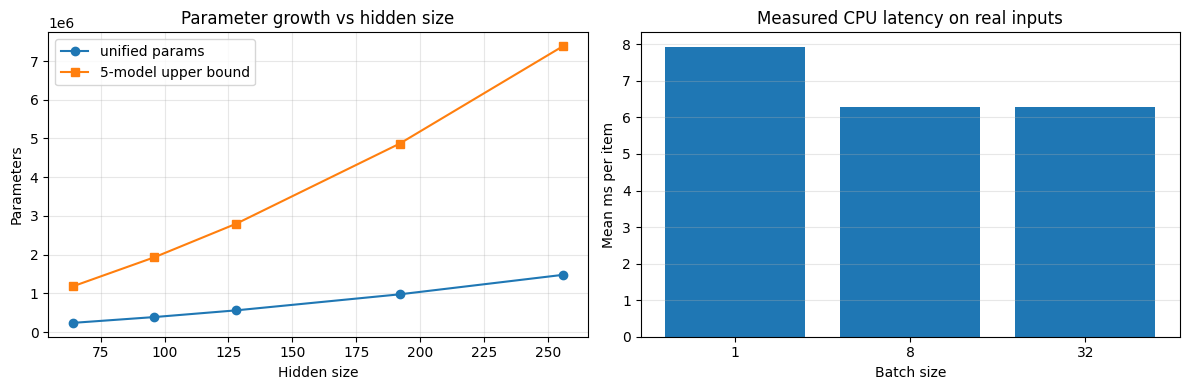

In [7]:
if plt is not None and pd is not None:
    hidden_df = pd.DataFrame(hidden_rows)
    bench_df = pd.DataFrame(benchmarks)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hidden_df["hidden"], hidden_df["params"], marker="o", label="unified params")
    axes[0].plot(
        hidden_df["hidden"],
        hidden_df["ladder_upper_bound_params"],
        marker="s",
        label="5-model upper bound",
    )
    axes[0].set_title("Parameter growth vs hidden size")
    axes[0].set_xlabel("Hidden size")
    axes[0].set_ylabel("Parameters")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].bar(bench_df["batch_size"].astype(str), bench_df["mean_item_ms"])
    axes[1].set_title("Measured CPU latency on real inputs")
    axes[1].set_xlabel("Batch size")
    axes[1].set_ylabel("Mean ms per item")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Plotting requires matplotlib and pandas.")

## Runtime-oriented takeaways

Use the measurements above to guide the next change:

- If latency is dominated by the current unified model, first try **smaller hidden sizes** or **low-rank child projection**.
- If upper levels are overprovisioned, a **shared trunk + tiny level-specific heads/adapters** is likely cheaper than a fully separate 5-model ladder.
- If the stronger unified model is clearly more accurate but too slow, **distillation** becomes attractive.
- If latency is already acceptable, improving data coverage and leaf accuracy is likely higher priority than architectural simplification.

## Baseline vs fast runtime comparison

This section benchmarks the trained `baseline_128` checkpoint, the smaller `fast_72` checkpoint, and the selected `fast_80` winner on the same real inputs, then compares checkpoint size, parameter count, and measured CPU latency.

,model,variant,hidden,params,checkpoint_kb,mean_item_ms,items_per_sec
1,fast_72,fast,72,212193,838.507812,2.395467,417.455104
0,baseline_128,baseline,128,559361,2190.958008,6.418636,155.796342


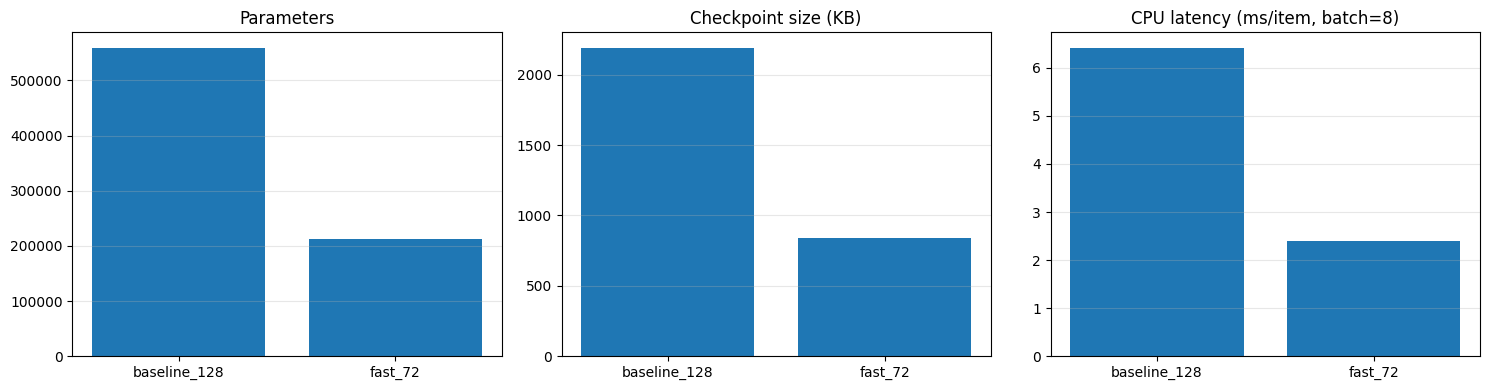

In [5]:
COMPARISON_CHECKPOINTS = {
    "baseline_128": REPO_ROOT / "tmp_real_sparse_root_model.pt",
    "fast_72": REPO_ROOT / "tmp_fast72_real_sparse_root.pt",
    "fast_80": REPO_ROOT / "tmp_fast80_real_sparse_root.pt",
}


def checkpoint_size_kb(path: Path) -> float:
    return path.stat().st_size / 1024.0


comparison_rows = []
for name, ckpt in COMPARISON_CHECKPOINTS.items():
    if not ckpt.exists():
        print("missing checkpoint:", ckpt)
        continue
    meta = checkpoint_metadata(ckpt)
    cmp_model = meta["model_cls"](
        n2d=N2D,
        n3d=N3D,
        hidden=meta["hidden"],
        num_classes=meta["num_classes"],
    ).to(DEVICE)
    cmp_model.load_state_dict(meta["state"], strict=True)
    cmp_model.eval()

    bench = benchmark_inference(cmp_model, ds, batch_size=8, steps=64)
    comparison_rows.append(
        {
            "model": name,
            "variant": meta["variant"],
            "hidden": meta["hidden"],
            "params": count_parameters(cmp_model),
            "checkpoint_kb": checkpoint_size_kb(ckpt),
            "mean_item_ms": bench["mean_item_ms"],
            "items_per_sec": bench["items_per_sec"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows) if pd is not None else comparison_rows
if pd is not None and comparison_rows:
    display(comparison_df.sort_values("mean_item_ms"))
else:
    print(comparison_rows)

if plt is not None and pd is not None and comparison_rows:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].bar(comparison_df["model"], comparison_df["params"])
    axes[0].set_title("Parameters")
    axes[0].grid(True, axis="y", alpha=0.3)

    axes[1].bar(comparison_df["model"], comparison_df["checkpoint_kb"])
    axes[1].set_title("Checkpoint size (KB)")
    axes[1].grid(True, axis="y", alpha=0.3)

    axes[2].bar(comparison_df["model"], comparison_df["mean_item_ms"])
    axes[2].set_title("CPU latency (ms/item, batch=8)")
    axes[2].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

## Refreshed 4-way runtime comparison

This reruns the explicit runtime comparison using fixed checkpoint paths for `baseline_128`, `fast_72`, `fast_80`, and the distilled `fast_80_distilled` student.

,model,variant,hidden,num_classes,params,checkpoint_kb,mean_item_ms,items_per_sec
1,fast_72,fast,72,1040,212193,838.507812,3.492053,286.364486
2,fast_80,fast,80,1040,247067,974.820312,5.885286,169.915278
3,fast_80_distilled,fast,80,2048,301499,1187.678711,5.903769,169.383328
0,baseline_128,baseline,128,2048,559361,2190.958008,7.197217,138.942590


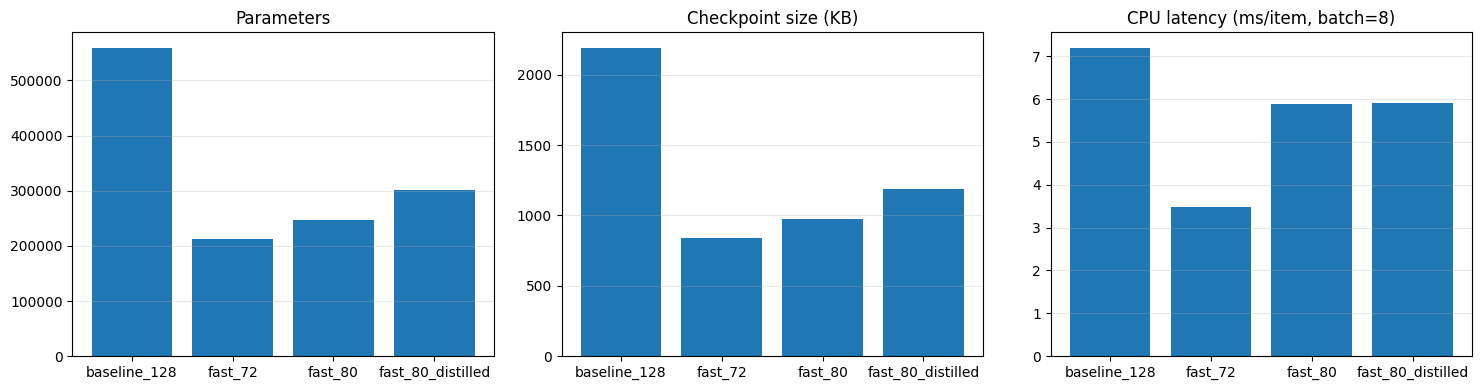

In [11]:
REFRESHED_COMPARISON_CHECKPOINTS = {
    "baseline_128": REPO_ROOT / "tmp_real_sparse_root_model.pt",
    "fast_72": REPO_ROOT / "tmp_fast72_real_sparse_root.pt",
    "fast_80": REPO_ROOT / "tmp_fast80_real_sparse_root.pt",
    "fast_80_distilled": REPO_ROOT / "tmp_fast80_distilled_sparse_root.pt",
}

refreshed_runtime_rows = []
for name, ckpt in REFRESHED_COMPARISON_CHECKPOINTS.items():
    if not ckpt.exists():
        print("missing checkpoint:", ckpt)
        continue
    meta = checkpoint_metadata(ckpt)
    cmp_model = meta["model_cls"](
        n2d=N2D,
        n3d=N3D,
        hidden=meta["hidden"],
        num_classes=meta["num_classes"],
    ).to(DEVICE)
    cmp_model.load_state_dict(meta["state"], strict=True)
    cmp_model.eval()
    bench = benchmark_inference(cmp_model, ds, batch_size=8, steps=64)
    refreshed_runtime_rows.append(
        {
            "model": name,
            "variant": meta["variant"],
            "hidden": meta["hidden"],
            "num_classes": meta["num_classes"],
            "params": count_parameters(cmp_model),
            "checkpoint_kb": checkpoint_size_kb(ckpt),
            "mean_item_ms": bench["mean_item_ms"],
            "items_per_sec": bench["items_per_sec"],
        }
    )

refreshed_runtime_df = (
    pd.DataFrame(refreshed_runtime_rows) if pd is not None else refreshed_runtime_rows
)
if pd is not None and refreshed_runtime_rows:
    display(refreshed_runtime_df.sort_values("mean_item_ms"))
else:
    print(refreshed_runtime_rows)

if plt is not None and pd is not None and refreshed_runtime_rows:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].bar(refreshed_runtime_df["model"], refreshed_runtime_df["params"])
    axes[0].set_title("Parameters")
    axes[0].grid(True, axis="y", alpha=0.3)
    axes[1].bar(refreshed_runtime_df["model"], refreshed_runtime_df["checkpoint_kb"])
    axes[1].set_title("Checkpoint size (KB)")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[2].bar(refreshed_runtime_df["model"], refreshed_runtime_df["mean_item_ms"])
    axes[2].set_title("CPU latency (ms/item, batch=8)")
    axes[2].grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()